# Single-LoS GLRT AoA Simu



In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True
np.set_printoptions(precision=4, suppress=True)

In [2]:
def steering_vector(theta_deg, M, d_over_lambda=0.5):
    """Normalized ULA steering vector.

    Args:
        theta_deg: AoA in degrees (scalar or vector).
        M: number of receive antennas (array elements).
        d_over_lambda: antenna spacing normalized by wavelength.
    """
    theta_deg_arr = np.atleast_1d(theta_deg).astype(float)
    theta_rad = np.deg2rad(theta_deg_arr)
    m = np.arange(M, dtype=float)
    phase = 2.0 * np.pi * d_over_lambda * np.outer(m, np.sin(theta_rad))
    A = np.exp(1j * phase) / np.sqrt(M)
    if np.ndim(theta_deg) == 0:
        return A[:, 0]
    return A


def square_qam_symbols(T, order=16, rng=None):
    """Generate unit-power square QAM symbols."""
    if T < 1:
        raise ValueError('T must be >= 1 (number of snapshots).')

    if rng is None:
        rng = np.random.default_rng()

    m = int(np.sqrt(order))
    if m * m != order:
        raise ValueError('order must be a perfect square, e.g. 4, 16, 64.')

    levels = np.arange(-(m - 1), m, 2)
    i = rng.choice(levels, size=T)
    q = rng.choice(levels, size=T)
    s = i + 1j * q
    s = s / np.sqrt(np.mean(np.abs(s) ** 2))
    return s


def simulate_h1(theta_deg, snr_db, M, T, sigma2=1.0, qam_order=16, d_over_lambda=0.5, rng=None):
    """Simulate H1: Y = u b^T + W."""
    if M < 1 or T < 1:
        raise ValueError('M and T must both be >= 1.')

    if rng is None:
        rng = np.random.default_rng()

    u_true = steering_vector(theta_deg, M, d_over_lambda)
    s = square_qam_symbols(T, order=qam_order, rng=rng)

    # SNR definition: E[||u g s||^2] / E[||w||^2] = |g|^2 / (M * sigma2).
    snr_lin = 10.0 ** (snr_db / 10.0)
    g_mag = np.sqrt(snr_lin * M * sigma2)
    g = g_mag * np.exp(1j * rng.uniform(0.0, 2.0 * np.pi))

    b = g * s
    noise = np.sqrt(sigma2 / 2.0) * (
        rng.standard_normal((M, T)) + 1j * rng.standard_normal((M, T))
    )
    Y = np.outer(u_true, b) + noise
    return Y, u_true, b, g


def simulate_h0(M, T, sigma2=1.0, rng=None):
    """Simulate H0: Y = W."""
    if M < 1 or T < 1:
        raise ValueError('M and T must both be >= 1.')

    if rng is None:
        rng = np.random.default_rng()

    return np.sqrt(sigma2 / 2.0) * (
        rng.standard_normal((M, T)) + 1j * rng.standard_normal((M, T))
    )


def analyze_snapshot(Y, angle_grid_deg, d_over_lambda=0.5):
    """Compute dominant eigenvector, AoA estimate, and GLRT statistic."""
    M, T = Y.shape
    if M < 1 or T < 1:
        raise ValueError('Y must have shape (M, T) with M,T >= 1.')

    R = (Y @ Y.conj().T) / T
    eigvals, eigvecs = np.linalg.eigh(R)

    lambda_max = float(np.real(eigvals[-1]))
    tr_R = float(np.real(np.trace(R)))
    if tr_R <= 0.0:
        raise ValueError('Trace(R) must be > 0. Check input and sigma2.')

    # Numerical guard: for T=1 and/or high SNR, xi can be extremely close to 1.
    # Clip to avoid log(0) or log of a negative value due to floating-point error.
    xi_raw = lambda_max / tr_R
    eps = 1e-12
    xi = float(np.clip(xi_raw, 0.0, 1.0 - eps))
    log_glrt = float(M * T * (-np.log1p(-xi)))

    u_hat = eigvecs[:, -1]
    A = steering_vector(angle_grid_deg, M, d_over_lambda)
    spectrum = np.abs(A.conj().T @ u_hat) ** 2
    theta_hat = float(angle_grid_deg[np.argmax(spectrum)])

    return {
        'R': R,
        'u_hat': u_hat,
        'theta_hat': theta_hat,
        'spectrum': spectrum,
        'lambda_max': lambda_max,
        'trace_R': tr_R,
        'xi_raw': float(xi_raw),
        'xi': xi,
        'log_glrt': log_glrt,
    }


def calibrate_xi_threshold(M, T, pfa, n_trials, sigma2=1.0, seed=1):
    """Monte-Carlo threshold calibration for target false-alarm rate."""
    if M < 1 or T < 1:
        raise ValueError('M and T must both be >= 1.')

    rng = np.random.default_rng(seed)
    xi_h0 = np.empty(n_trials)
    eps = 1e-12

    for k in range(n_trials):
        Y0 = simulate_h0(M=M, T=T, sigma2=sigma2, rng=rng)
        M0, T0 = Y0.shape
        R0 = (Y0 @ Y0.conj().T) / T0
        eigvals0 = np.linalg.eigvalsh(R0)
        xi_raw = float(np.real(eigvals0[-1] / np.trace(R0)))
        xi_h0[k] = float(np.clip(xi_raw, 0.0, 1.0 - eps))

    xi_threshold = float(np.quantile(xi_h0, 1.0 - pfa))
    xi_threshold = float(np.clip(xi_threshold, 0.0, 1.0 - eps))
    psi_threshold = float(M * T * (-np.log1p(-xi_threshold)))
    return xi_threshold, psi_threshold, xi_h0


In [3]:
# Baseline setup
# M: number of receive antennas
M = 8
# T: number of snapshots (time samples)
T = 16
# sigma2: noise variance per receive dimension
sigma2 = 1.0
# constellation order for s(t), 4/16/64
qam_order = 16
d_over_lambda = 0.5
# grid for AoA search in Eq. theta_hat = argmax |a(theta)^H u_hat|^2
angle_grid_deg = np.linspace(-90.0, 90.0, 1441)
theta_true_deg = 10.0
snr_db_single = 5.0
rng_single = np.random.default_rng(2026)

# For this xi-GLRT (unknown sigma2), T=1 is degenerate: xi = lambda_max/trace ~= 1 under both H0/H1.
# So AoA estimation still works, but GLRT threshold/Pfa/Pd evaluation is skipped when T=1.
enable_glrt_eval = T >= 2
if not enable_glrt_eval:
    print('[warning] T=1: xi-GLRT detection is degenerate; only AoA estimation metrics are meaningful.')

# Calibrate xi threshold under H0 for desired Pfa
pfa_target = 1e-4
n_h0_cal = 6000

if enable_glrt_eval:
    xi_th, psi_th, xi_h0_cal = calibrate_xi_threshold(
        M=M,
        T=T,
        pfa=pfa_target,
        n_trials=n_h0_cal,
        sigma2=sigma2,
        seed=17,
    )
else:
    xi_th = np.nan
    psi_th = np.nan
    xi_h0_cal = np.array([])

Y, u_true, b_true, g_true = simulate_h1(
    theta_deg=theta_true_deg,
    snr_db=snr_db_single,
    M=M,
    T=T,
    sigma2=sigma2,
    qam_order=qam_order,
    d_over_lambda=d_over_lambda,
    rng=rng_single,
)

single = analyze_snapshot(Y, angle_grid_deg=angle_grid_deg, d_over_lambda=d_over_lambda)

# Backward compatibility: old analyze_snapshot may not return xi_raw.
if 'xi_raw' not in single:
    single['xi_raw'] = float(single['xi'])

theta_hat_deg = single['theta_hat']
u_alignment = np.abs(np.vdot(u_true, single['u_hat'])) ** 2

if enable_glrt_eval:
    detect_h1 = single['xi'] > xi_th
    decision_text = 'H1: detect signal'
    if not detect_h1:
        decision_text = 'H0: no reliable signal'
else:
    detect_h1 = True
    decision_text = 'GLRT skipped (T=1 degenerate)'

print()
print('=== Detection ===')
print(f'decision: {decision_text}')
if enable_glrt_eval:
    print(f'target Pfa: {pfa_target:.1e}')
    print(f'use AoA estimate: {detect_h1}')
else:
    print('target Pfa: N/A (GLRT disabled)')
    print('use AoA estimate: True (estimation-only mode)')

print()
print('=== GLRT Statistics ===')
if enable_glrt_eval:
    print(f'xi = {single["xi"]:.6f} | xi_th = {xi_th:.6f}')
    print(f'log GLRT = {single["log_glrt"]:.4f} | psi_th = {psi_th:.4f}')
else:
    print(f'xi = {single["xi"]:.6f} | xi_th = N/A')
    print(f'log GLRT = {single["log_glrt"]:.4f} | psi_th = N/A')
print(f'xi_raw = {single["xi_raw"]:.6f}')

print()
print('=== AoA Metrics ===')
print(f'theta_true (deg): {theta_true_deg:.2f}')
print(f'theta_hat  (deg): {theta_hat_deg:.2f}')
print(f'abs error  (deg): {abs(theta_hat_deg - theta_true_deg):.2f}')
print(f'u alignment |u^H u_hat|^2: {u_alignment:.4f}')



=== Detection ===
decision: H1: detect signal
target Pfa: 1.0e-04
use AoA estimate: True

=== GLRT Statistics ===
xi = 0.791308 | xi_th = 0.406562
log GLRT = 200.5628 | psi_th = 66.7932
xi_raw = 0.791308

=== AoA Metrics ===
theta_true (deg): 10.00
theta_hat  (deg): 9.75
abs error  (deg): 0.25
u alignment |u^H u_hat|^2: 0.9795


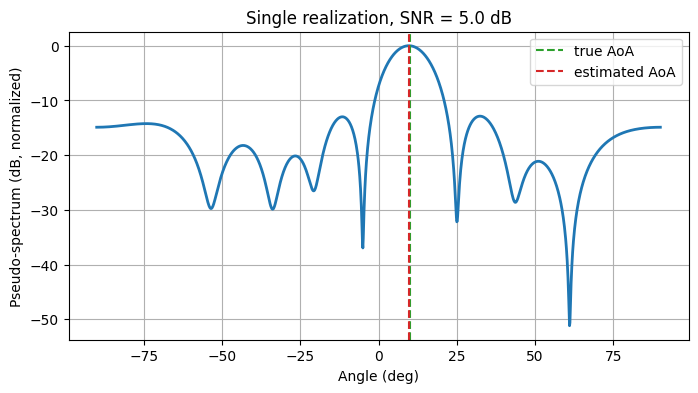

In [4]:
spectrum_db = 10.0 * np.log10(single['spectrum'] / np.max(single['spectrum']) + 1e-12)

fig, ax = plt.subplots()
ax.plot(angle_grid_deg, spectrum_db, lw=2)
ax.axvline(theta_true_deg, color='tab:green', ls='--', lw=1.5, label='true AoA')
ax.axvline(theta_hat_deg, color='tab:red', ls='--', lw=1.5, label='estimated AoA')
ax.set_xlabel('Angle (deg)')
ax.set_ylabel('Pseudo-spectrum (dB, normalized)')
ax.set_title(f'Single realization, SNR = {snr_db_single:.1f} dB')
ax.legend(loc='best')
plt.show()

Empirical Pfa on test set: 0.0003


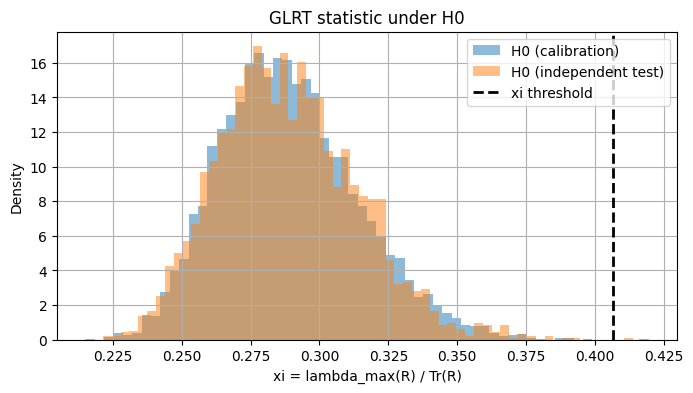

In [5]:
# Independent false-alarm check on fresh H0 data
if enable_glrt_eval:
    n_h0_test = 3000
    rng_fa = np.random.default_rng(99)
    xi_h0_test = np.empty(n_h0_test)

    for k in range(n_h0_test):
        Y0 = simulate_h0(M=M, T=T, sigma2=sigma2, rng=rng_fa)
        out0 = analyze_snapshot(Y0, angle_grid_deg=angle_grid_deg, d_over_lambda=d_over_lambda)
        xi_h0_test[k] = out0['xi']

    empirical_pfa = np.mean(xi_h0_test > xi_th)
    print(f'Empirical Pfa on test set: {empirical_pfa:.4f}')

    fig, ax = plt.subplots()
    ax.hist(xi_h0_cal, bins=60, alpha=0.5, density=True, label='H0 (calibration)')
    ax.hist(xi_h0_test, bins=60, alpha=0.5, density=True, label='H0 (independent test)')
    ax.axvline(xi_th, color='k', ls='--', lw=2, label='xi threshold')
    ax.set_xlabel('xi = lambda_max(R) / Tr(R)')
    ax.set_ylabel('Density')
    ax.set_title('GLRT statistic under H0')
    ax.legend(loc='best')
    plt.show()
else:
    xi_h0_test = np.array([])
    empirical_pfa = np.nan
    print('[warning] False-alarm evaluation skipped because T=1.')


At SNR=5.0 dB, estimated Pd: 1.0000


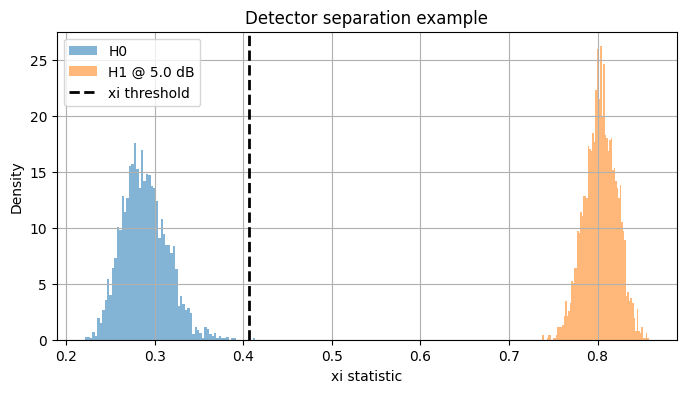

In [6]:
# Separation view: H0 vs H1 xi distributions at a selected SNR
snr_hist_db = snr_db_single
theta_hist_deg = theta_true_deg
n_hist = 3000

if enable_glrt_eval:
    rng_hist = np.random.default_rng(123)
    xi_h1_hist = np.empty(n_hist)

    for k in range(n_hist):
        Y1, _, _, _ = simulate_h1(
            theta_deg=theta_hist_deg,
            snr_db=snr_hist_db,
            M=M,
            T=T,
            sigma2=sigma2,
            qam_order=qam_order,
            d_over_lambda=d_over_lambda,
            rng=rng_hist,
        )
        out1 = analyze_snapshot(Y1, angle_grid_deg=angle_grid_deg, d_over_lambda=d_over_lambda)
        xi_h1_hist[k] = out1['xi']

    pd_hist = np.mean(xi_h1_hist > xi_th)
    print(f'At SNR={snr_hist_db:.1f} dB, estimated Pd: {pd_hist:.4f}')

    fig, ax = plt.subplots()
    ax.hist(xi_h0_test, bins=70, alpha=0.55, density=True, label='H0')
    ax.hist(xi_h1_hist, bins=70, alpha=0.55, density=True, label=f'H1 @ {snr_hist_db:.1f} dB')
    ax.axvline(xi_th, color='k', ls='--', lw=2, label='xi threshold')
    ax.set_xlabel('xi statistic')
    ax.set_ylabel('Density')
    ax.set_title('Detector separation example')
    ax.legend(loc='best')
    plt.show()
else:
    xi_h1_hist = np.array([])
    pd_hist = np.nan
    print('[warning] Detector separation plot skipped because T=1.')


In [7]:
# Monte Carlo performance sweep versus SNR
snr_grid_db = np.arange(-18, 13, 3)
n_trials_per_snr = 1200
theta_true_mc = theta_true_deg
rng_mc = np.random.default_rng(2027)

pd = np.full(len(snr_grid_db), np.nan)
rmse_all = np.empty(len(snr_grid_db))
rmse_det = np.full(len(snr_grid_db), np.nan)
u_align_mean = np.empty(len(snr_grid_db))

for i, snr_db in enumerate(snr_grid_db):
    det_flags = np.zeros(n_trials_per_snr, dtype=bool)
    theta_errors = np.empty(n_trials_per_snr)
    u_align = np.empty(n_trials_per_snr)

    for n in range(n_trials_per_snr):
        Y1, u_true, _, _ = simulate_h1(
            theta_deg=theta_true_mc,
            snr_db=snr_db,
            M=M,
            T=T,
            sigma2=sigma2,
            qam_order=qam_order,
            d_over_lambda=d_over_lambda,
            rng=rng_mc,
        )

        out = analyze_snapshot(Y1, angle_grid_deg=angle_grid_deg, d_over_lambda=d_over_lambda)

        if enable_glrt_eval:
            det_flags[n] = out['xi'] > xi_th
        theta_errors[n] = out['theta_hat'] - theta_true_mc
        u_align[n] = np.abs(np.vdot(u_true, out['u_hat'])) ** 2

    if enable_glrt_eval:
        pd[i] = np.mean(det_flags)
        rmse_det[i] = np.sqrt(np.mean(theta_errors[det_flags] ** 2)) if np.any(det_flags) else np.nan

    rmse_all[i] = np.sqrt(np.mean(theta_errors ** 2))
    u_align_mean[i] = np.mean(u_align)

print('Sweep complete.')


Sweep complete.


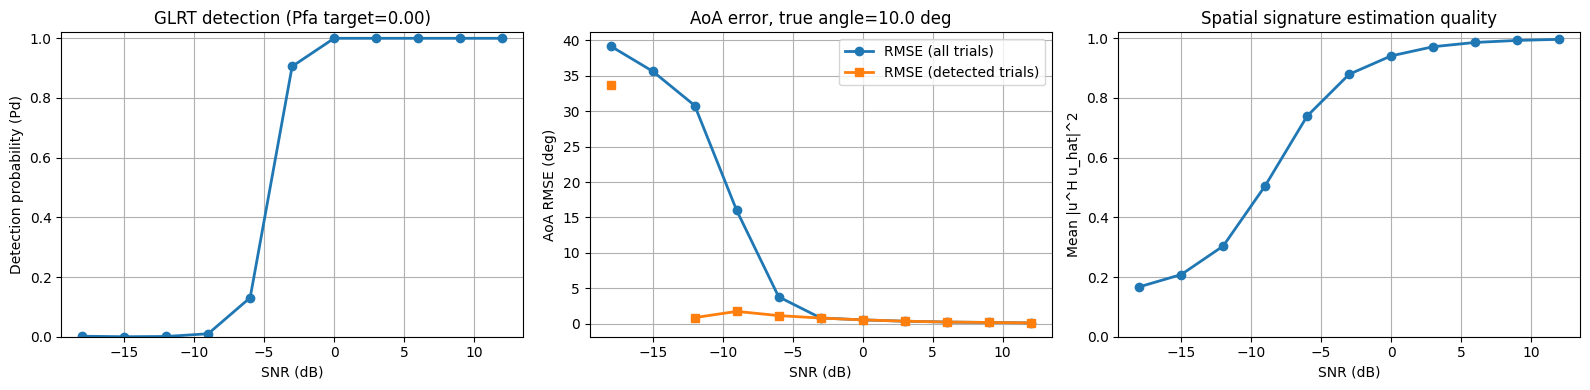

SNR(dB) |   Pd   | RMSE_all | RMSE_detected | mean|u^H u_hat|^2
  -18.0 |  0.002 |   39.171 |        33.756 |           0.1671
  -15.0 |  0.000 |   35.624 |           nan |           0.2083
  -12.0 |  0.001 |   30.795 |         0.875 |           0.3040
   -9.0 |  0.010 |   15.997 |         1.753 |           0.5059
   -6.0 |  0.131 |    3.806 |         1.159 |           0.7395
   -3.0 |  0.906 |    0.828 |         0.813 |           0.8794
    0.0 |  1.000 |    0.556 |         0.556 |           0.9410
    3.0 |  1.000 |    0.370 |         0.370 |           0.9718
    6.0 |  1.000 |    0.252 |         0.252 |           0.9861
    9.0 |  1.000 |    0.190 |         0.190 |           0.9929
   12.0 |  1.000 |    0.131 |         0.131 |           0.9965


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

if enable_glrt_eval:
    axes[0].plot(snr_grid_db, pd, marker='o', lw=2)
    axes[0].set_ylabel('Detection probability (Pd)')
    axes[0].set_ylim(0.0, 1.02)
    axes[0].set_title(f'GLRT detection (Pfa target={pfa_target:.2f})')
else:
    axes[0].text(0.5, 0.5, 'GLRT skipped for T=1\n(xi statistic is degenerate)', ha='center', va='center')
    axes[0].set_ylabel('Detection probability (Pd)')
    axes[0].set_ylim(0.0, 1.02)
    axes[0].set_title('GLRT detection not applicable')
axes[0].set_xlabel('SNR (dB)')

axes[1].plot(snr_grid_db, rmse_all, marker='o', lw=2, label='RMSE (all trials)')
if enable_glrt_eval:
    axes[1].plot(snr_grid_db, rmse_det, marker='s', lw=2, label='RMSE (detected trials)')
axes[1].set_xlabel('SNR (dB)')
axes[1].set_ylabel('AoA RMSE (deg)')
axes[1].set_title(f'AoA error, true angle={theta_true_mc:.1f} deg')
axes[1].legend(loc='best')

axes[2].plot(snr_grid_db, u_align_mean, marker='o', lw=2)
axes[2].set_xlabel('SNR (dB)')
axes[2].set_ylabel('Mean |u^H u_hat|^2')
axes[2].set_ylim(0.0, 1.02)
axes[2].set_title('Spatial signature estimation quality')

plt.tight_layout()
plt.show()

print('SNR(dB) |   Pd   | RMSE_all | RMSE_detected | mean|u^H u_hat|^2')
for s, a, b, c, d in zip(snr_grid_db, pd, rmse_all, rmse_det, u_align_mean):
    print(f'{s:7.1f} | {a:6.3f} | {b:8.3f} | {c:13.3f} | {d:16.4f}')


## Nulling and INR vs SNR

This section uses your GLRT-estimated spatial signature as $\hat{u}_1$, then forms
a nulling beam toward a known desired-user direction $u_0$. We compare:

- No nulling (use $u_0$ directly)
- Oracle nulling (use true $u_1$)
- Practical nulling (use estimated $\hat{u}_1$)

INR is evaluated as $\mathrm{INR}=\gamma|v^H u_1|^2$.

In [9]:
def nulling_vector(u0, u_ref, eps=1e-12):
    """
    Construct v that maximizes |v^H u0|^2 subject to v^H u_ref = 0.
    Returns unit-norm v.
    """
    rho = np.vdot(u_ref, u0)
    denom = 1.0 - np.abs(rho) ** 2

    if denom <= eps:
        # Degenerate case: u0 almost parallel to u_ref.
        # Build any stable unit vector orthogonal to u_ref.
        e = np.zeros_like(u_ref)
        e[np.argmin(np.abs(u_ref))] = 1.0
        v = e - np.vdot(u_ref, e) * u_ref
        v_norm = np.linalg.norm(v)
        if v_norm <= eps:
            raise ValueError('Failed to build an orthogonal nulling vector.')
        return v / v_norm, rho

    v = (u0 - rho * u_ref) / np.sqrt(denom)
    v = v / np.linalg.norm(v)
    return v, rho


In [10]:
# INR simulation setup
from tqdm.auto import tqdm

theta0_deg = 0.0    # desired user angle: u0 is assumed perfectly known
theta1_deg = 18.0   # true interferer angle: u1
# Log-spaced SNR grid: linear gamma is equally spaced on a log scale
snr_lin_grid_inr = np.logspace(-15.0 / 10.0, 10.0 / 10.0, 150)
snr_grid_db_inr = 10.0 * np.log10(snr_lin_grid_inr)
n_trials_inr = 1500
rng_inr = np.random.default_rng(404)

u0 = steering_vector(theta0_deg, M, d_over_lambda)
u1 = steering_vector(theta1_deg, M, d_over_lambda)

inr_no_null_db = np.empty(len(snr_grid_db_inr))
inr_oracle_db = np.empty(len(snr_grid_db_inr))
inr_est_db = np.empty(len(snr_grid_db_inr))
u1_align_mean = np.empty(len(snr_grid_db_inr))
orth_err_mean = np.empty(len(snr_grid_db_inr))

# Save terms needed for eta/alpha/beta validation
beta = T / M
tau_u_mean = np.empty(len(snr_grid_db_inr))
tau_v_mean = np.empty(len(snr_grid_db_inr))
tau_w_mean = np.empty(len(snr_grid_db_inr))
alpha_mean = np.empty(len(snr_grid_db_inr))
alpha_over_beta_mean = np.empty(len(snr_grid_db_inr))
eta_emp_mean = np.empty(len(snr_grid_db_inr))
eta_theory_exact_mean = np.empty(len(snr_grid_db_inr))
eta_theory_approx_mean = np.empty(len(snr_grid_db_inr))
eta_theory_exact_uhat_mean = np.empty(len(snr_grid_db_inr))
eta_theory_approx_uhat_mean = np.empty(len(snr_grid_db_inr))

for i, gamma_lin in enumerate(tqdm(snr_lin_grid_inr, desc='SNR grid')):
    snr_db = snr_grid_db_inr[i]

    inr_no_trials = np.empty(n_trials_inr)
    inr_oracle_trials = np.empty(n_trials_inr)
    inr_est_trials = np.empty(n_trials_inr)
    align_trials = np.empty(n_trials_inr)
    orth_err_trials = np.empty(n_trials_inr)

    tau_u_trials = np.empty(n_trials_inr)
    tau_v_trials = np.empty(n_trials_inr)
    tau_w_trials = np.empty(n_trials_inr)
    alpha_trials = np.empty(n_trials_inr)
    eta_theory_trials = np.empty(n_trials_inr)
    eta_approx_trials = np.empty(n_trials_inr)
    eta_theory_uhat_trials = np.empty(n_trials_inr)
    eta_approx_uhat_trials = np.empty(n_trials_inr)

    for n in tqdm(range(n_trials_inr), desc=f'Trials @ {snr_db:.1f} dB', leave=False):
        Y, u1_true, b_vec, g_true = simulate_h1(
            theta_deg=theta1_deg,
            snr_db=snr_db,
            M=M,
            T=T,
            sigma2=sigma2,
            qam_order=qam_order,
            d_over_lambda=d_over_lambda,
            rng=rng_inr,
        )

        out = analyze_snapshot(Y, angle_grid_deg=angle_grid_deg, d_over_lambda=d_over_lambda)
        u1_hat = out['u_hat']

        # v_oracle: null with perfect interferer signature u1
        v_oracle, _ = nulling_vector(u0, u1_true)
        # v_est: null with estimated interferer signature u1hat
        v_est, _ = nulling_vector(u0, u1_hat)

        inr_no_trials[n] = gamma_lin * np.abs(np.vdot(u0, u1_true)) ** 2
        inr_oracle_trials[n] = gamma_lin * np.abs(np.vdot(v_oracle, u1_true)) ** 2
        inr_est_trials[n] = gamma_lin * np.abs(np.vdot(v_est, u1_true)) ** 2

        align_trials[n] = np.abs(np.vdot(u1_true, u1_hat)) ** 2
        orth_err_trials[n] = np.abs(np.vdot(v_est, u1_hat)) ** 2

        # ---- eta/alpha/beta terms from your LaTeX notes ----
        # tau_u = gamma * E|u_i|^2
        tau_u = gamma_lin * np.mean(np.abs(u1_true) ** 2)

        # b_vec = g_true * s. To avoid counting gamma twice, remove g_true from b_vec.
        # Then tau_v corresponds to symbol power E|s_j|^2 (about 1 after normalization).
        tau_v = np.mean(np.abs(b_vec / (g_true + 1e-15)) ** 2)

        # tau_w = E|W_ij|^2 / M, and E|W_ij|^2 = sigma2 for CN(0, sigma2)
        tau_w = sigma2 / M

        alpha = tau_w / (tau_u * tau_v)
        eta_exact = (beta - alpha ** 2) / (beta + alpha)
        eta_approx = 1.0 - alpha / beta

        tau_u_hat = gamma_lin * np.mean(np.abs(u1_hat) ** 2)
        alpha_uhat = tau_w / (tau_u_hat * tau_v)
        eta_exact_uhat = (beta - alpha_uhat ** 2) / (beta + alpha_uhat)
        eta_approx_uhat = 1.0 - alpha_uhat / beta

        tau_u_trials[n] = tau_u
        tau_v_trials[n] = tau_v
        tau_w_trials[n] = tau_w
        alpha_trials[n] = alpha
        eta_theory_trials[n] = eta_exact
        eta_approx_trials[n] = eta_approx
        eta_theory_uhat_trials[n] = eta_exact_uhat
        eta_approx_uhat_trials[n] = eta_approx_uhat

    inr_no_null_db[i] = 10.0 * np.log10(np.mean(inr_no_trials) + 1e-15)
    inr_oracle_db[i] = 10.0 * np.log10(np.mean(inr_oracle_trials) + 1e-15)
    inr_est_db[i] = 10.0 * np.log10(np.mean(inr_est_trials) + 1e-15)

    u1_align_mean[i] = np.mean(align_trials)
    orth_err_mean[i] = np.mean(orth_err_trials)

    tau_u_mean[i] = np.mean(tau_u_trials)
    tau_v_mean[i] = np.mean(tau_v_trials)
    tau_w_mean[i] = np.mean(tau_w_trials)
    alpha_mean[i] = np.mean(alpha_trials)
    alpha_over_beta_mean[i] = np.mean(alpha_trials / beta)

    eta_emp_mean[i] = np.mean(align_trials)
    eta_theory_exact_mean[i] = np.mean(eta_theory_trials)
    eta_theory_approx_mean[i] = np.mean(eta_approx_trials)
    eta_theory_exact_uhat_mean[i] = np.mean(eta_theory_uhat_trials)
    eta_theory_approx_uhat_mean[i] = np.mean(eta_approx_uhat_trials)

eta_err_exact = np.abs(eta_emp_mean - eta_theory_exact_mean)
eta_err_approx = np.abs(eta_emp_mean - eta_theory_approx_mean)


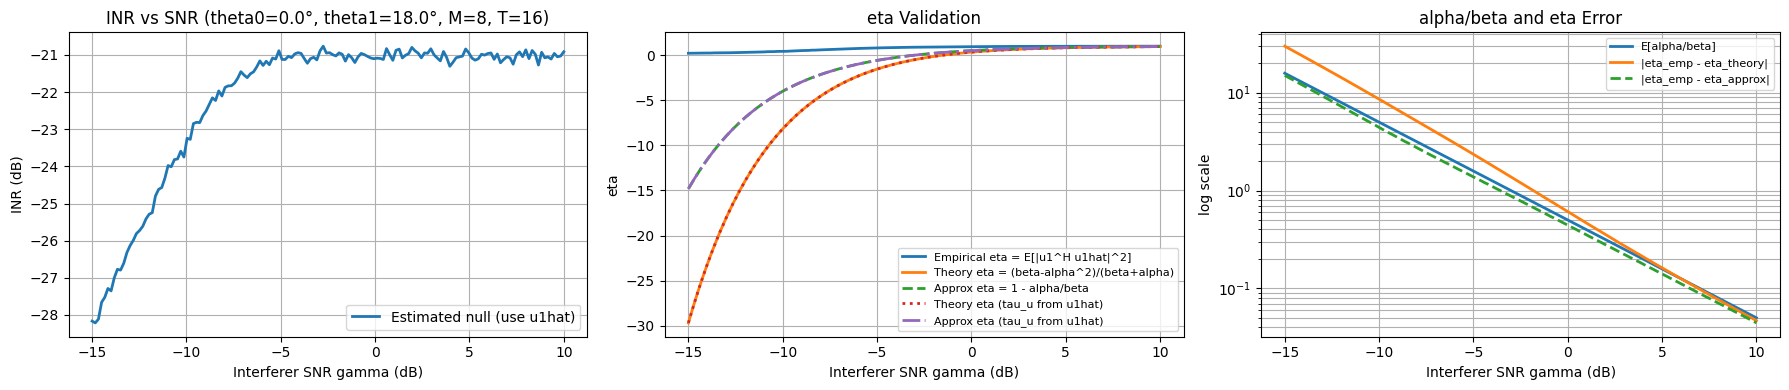

beta = T/M = 2.000000
alpha/beta range: [5.000e-02, 1.581e+01]
mean |eta_emp - eta_theory|  = 4.814e+00
mean |eta_emp - eta_approx| = 2.523e+00


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1) INR curves
# axes[0].plot(snr_grid_db_inr, inr_no_null_db, lw=2, label='No nulling (v=u0)')
# axes[0].plot(snr_grid_db_inr, inr_oracle_db, lw=2, label='Oracle null (use true u1)')
axes[0].plot(snr_grid_db_inr, inr_est_db, lw=2, label='Estimated null (use u1hat)')
axes[0].set_xlabel('Interferer SNR gamma (dB)')
axes[0].set_ylabel('INR (dB)')
axes[0].set_title(f'INR vs SNR (theta0={theta0_deg:.1f}°, theta1={theta1_deg:.1f}°, M={M}, T={T})')
axes[0].legend(loc='best')
axes[0].grid(True)

# 2) eta validation: simulation vs theory
axes[1].plot(snr_grid_db_inr, eta_emp_mean, lw=2, label='Empirical eta = E[|u1^H u1hat|^2]')
axes[1].plot(snr_grid_db_inr, eta_theory_exact_mean, lw=2, label='Theory eta = (beta-alpha^2)/(beta+alpha)')
axes[1].plot(snr_grid_db_inr, eta_theory_approx_mean, '--', lw=2, label='Approx eta = 1 - alpha/beta')
axes[1].plot(snr_grid_db_inr, eta_theory_exact_uhat_mean, ':', lw=2, label='Theory eta (tau_u from u1hat)')
axes[1].plot(snr_grid_db_inr, eta_theory_approx_uhat_mean, '-.', lw=2, label='Approx eta (tau_u from u1hat)')
axes[1].set_xlabel('Interferer SNR gamma (dB)')
axes[1].set_ylabel('eta')
axes[1].set_title('eta Validation')
axes[1].legend(loc='best', fontsize=8)
axes[1].grid(True)

# 3) alpha/beta check + eta fitting error
axes[2].semilogy(snr_grid_db_inr, np.maximum(alpha_over_beta_mean, 1e-16), lw=2, label='E[alpha/beta]')
axes[2].semilogy(snr_grid_db_inr, np.maximum(eta_err_exact, 1e-16), lw=2, label='|eta_emp - eta_theory|')
axes[2].semilogy(snr_grid_db_inr, np.maximum(eta_err_approx, 1e-16), '--', lw=2, label='|eta_emp - eta_approx|')
axes[2].set_xlabel('Interferer SNR gamma (dB)')
axes[2].set_ylabel('log scale')
axes[2].set_title('alpha/beta and eta Error')
axes[2].legend(loc='best', fontsize=8)
axes[2].grid(True, which='both')

plt.tight_layout()
plt.show()

print(f'beta = T/M = {beta:.6f}')
print(f'alpha/beta range: [{np.min(alpha_over_beta_mean):.3e}, {np.max(alpha_over_beta_mean):.3e}]')
print(f'mean |eta_emp - eta_theory|  = {np.mean(eta_err_exact):.3e}')
print(f'mean |eta_emp - eta_approx| = {np.mean(eta_err_approx):.3e}')
